# Expedia Review ROI and Sweepstakes Optimization

This notebook estimates how much **more reviews** and **better reviews** could be worth to Expedia, and compares that value to the cost of a **sweepstakes incentive** to find an economically sensible prize amount.

It is built around the prototype mechanic where:

- verified travelers answer adaptive review prompts
- each answered prompt adds a sweepstakes entry
- the product improves both review completion and review detail

The public Expedia / One Key facts are sourced. The conversion impact of better review coverage is a transparent scenario assumption you can edit for the pitch.


## Modeling Notes

The notebook values review improvements through two channels:

- **more reviews**: better freshness and review coverage
- **better reviews**: more answered prompts on high-value topics like location, value, and check-in

Those improvements are translated into incremental B2C gross bookings, revenue, and adjusted EBITDA. The optimization target is:

`incremental EBITDA - expected economic sweepstakes cost`


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown


DATA_DIR = Path(".")
OUTPUT_DIR = DATA_DIR / "review_sweepstakes_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

PALETTE = {
    "navy": "#0B1F3A",
    "blue": "#2C7FB8",
    "sky": "#89BEDC",
    "teal": "#1B998B",
    "gold": "#F3A712",
    "red": "#D1495B",
    "green": "#2F855A",
    "gray": "#6B7280",
}

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 10,
    }
)

pd.options.display.max_columns = 100
pd.options.display.float_format = lambda x: f"{x:,.4f}"


def usd(x):
    return f"${x:,.2f}"


def pct(x):
    return f"{x:.1%}"


def savefig(fig, name):
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight", dpi=220)
    fig.savefig(OUTPUT_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


print(f"Outputs will be written to: {OUTPUT_DIR.resolve()}")


Outputs will be written to: C:\VS Code\Projects\Wharton Hack-AI-Thon\review_sweepstakes_outputs


In [2]:
research_sources = pd.DataFrame(
    [
        {
            "source": "Expedia Group Q4 / full-year 2025 earnings release",
            "date": "Feb 12, 2026",
            "url": "https://www.sec.gov/Archives/edgar/data/1324424/000132442426000005/earningsrelease-q42025.htm",
            "key_fact": "2025 gross bookings were $119.59B and revenue was $14.733B.",
        },
        {
            "source": "Expedia Group partner page: distribute your inventory",
            "date": "Checked Apr 15, 2026",
            "url": "https://partner.expediagroup.com/en-us/solutions/distribute-your-inventory",
            "key_fact": "More than 168 million members and Expedia Group-funded OneKeyCash.",
        },
        {
            "source": "Expedia Group partner page: One Key travel rewards",
            "date": "Checked Apr 15, 2026",
            "url": "https://partner.expediagroup.com/en-us/solutions/distribute-your-inventory/one-key-travel-rewards",
            "key_fact": "Members generate 3x gross bookings per customer, 2.5x gross profit per customer, and 3x repeat business.",
        },
        {
            "source": "Expedia One Key terms and conditions",
            "date": "Effective Aug 13, 2025",
            "url": "https://www.expedia.com/lp/b/exp-rewards-terms",
            "key_fact": "$1 in OneKeyCash provides $1 in redemption value.",
        },
    ]
)

b2c_2025 = {
    "gross_bookings": np.array([22.615e9, 21.565e9, 21.343e9, 18.344e9]).sum(),
    "revenue": np.array([1.956e9, 2.479e9, 2.883e9, 2.156e9]).sum(),
    "adjusted_ebitda": np.array([0.217e9, 0.728e9, 1.174e9, 0.679e9]).sum(),
}
b2c_revenue_margin = b2c_2025["revenue"] / b2c_2025["gross_bookings"]
b2c_ebitda_margin = b2c_2025["adjusted_ebitda"] / b2c_2025["gross_bookings"]

reviews_raw = pd.read_csv(DATA_DIR / "Reviews_PROC.csv")
ratings = reviews_raw["rating"].apply(json.loads).apply(pd.Series).apply(pd.to_numeric, errors="coerce").fillna(0)
reviews = pd.concat([reviews_raw.drop(columns=["rating"]), ratings], axis=1)
reviews["review_title"] = reviews["review_title"].fillna("").astype(str)
reviews["review_text"] = reviews["review_text"].fillna("").astype(str)
reviews["review_full_text"] = (reviews["review_title"] + " " + reviews["review_text"]).str.strip()
reviews["word_count"] = reviews["review_full_text"].str.split().str.len().fillna(0).astype(int)
reviews["has_text"] = reviews["review_text"].str.strip().ne("")
reviews["overall_rating"] = pd.to_numeric(reviews["overall"], errors="coerce").replace(0, np.nan)
reviews = reviews.dropna(subset=["overall_rating"]).copy()

structured_cols = [c for c in ratings.columns if c != "overall"]
reviews["nonzero_structured_count"] = reviews[structured_cols].gt(0).sum(axis=1)
reviews["structured_coverage_share"] = reviews["nonzero_structured_count"] / len(structured_cols)
reviews["text_depth_score"] = (reviews["word_count"] / 40).clip(0, 1)
reviews["detail_index"] = 0.65 * reviews["structured_coverage_share"] + 0.35 * reviews["text_depth_score"]
reviews["moderate_rating"] = reviews["overall_rating"].between(3, 4)
reviews["short_or_missing_text"] = (~reviews["has_text"]) | (reviews["word_count"] < 20)
reviews["quiet_majority_candidate"] = reviews["moderate_rating"] | reviews["short_or_missing_text"]

gap_path = DATA_DIR / "analysis_outputs" / "importance_vs_coverage.csv"
if gap_path.exists():
    gap_topics = pd.read_csv(gap_path).sort_values("gap_score", ascending=False).copy()
else:
    gap_topics = pd.DataFrame(
        {
            "topic": structured_cols,
            "gap_score": [1 - reviews[c].gt(0).mean() for c in structured_cols],
        }
    ).sort_values("gap_score", ascending=False)

snapshot = pd.DataFrame(
    [
        ("Rated reviews", len(reviews)),
        ("Share with any text", reviews["has_text"].mean()),
        ("Share under 20 words", (reviews["word_count"] < 20).mean()),
        ("Median word count", float(reviews["word_count"].median())),
        ("Average non-zero structured subratings", reviews["nonzero_structured_count"].mean()),
        ("Average detail index", reviews["detail_index"].mean()),
        ("Moderate-rating share", reviews["moderate_rating"].mean()),
        ("Quiet-majority share", reviews["quiet_majority_candidate"].mean()),
        ("B2C revenue margin", b2c_revenue_margin),
        ("B2C adjusted EBITDA margin", b2c_ebitda_margin),
    ],
    columns=["Metric", "Value"],
)

snapshot.to_csv(OUTPUT_DIR / "review_quality_snapshot.csv", index=False)
research_sources.to_csv(OUTPUT_DIR / "research_sources.csv", index=False)
gap_topics.head(8).to_csv(OUTPUT_DIR / "top_gap_topics.csv", index=False)

display(Markdown("## Public Sources"))
display(research_sources)
display(Markdown("## Review Quality Snapshot"))
display(snapshot)
display(Markdown("## Highest-Value Gap Topics"))
display(gap_topics.head(8))


## Public Sources

,source,date,url,key_fact
0,Expedia Group Q4 / full-year 2025 earnings rel...,"Feb 12, 2026",https://www.sec.gov/Archives/edgar/data/132442...,2025 gross bookings were $119.59B and revenue ...
1,Expedia Group partner page: distribute your in...,"Checked Apr 15, 2026",https://partner.expediagroup.com/en-us/solutio...,More than 168 million members and Expedia Grou...
2,Expedia Group partner page: One Key travel rew...,"Checked Apr 15, 2026",https://partner.expediagroup.com/en-us/solutio...,Members generate 3x gross bookings per custome...
3,Expedia One Key terms and conditions,"Effective Aug 13, 2025",https://www.expedia.com/lp/b/exp-rewards-terms,$1 in OneKeyCash provides $1 in redemption value.


## Review Quality Snapshot

,Metric,Value
0,Rated reviews,"5,999.0000"
1,Share with any text,0.7098
2,Share under 20 words,0.6794
3,Median word count,10.0000
4,Average non-zero structured subratings,3.3666
5,Average detail index,0.2823
6,Moderate-rating share,0.3519
7,Quiet-majority share,0.8131
8,B2C revenue margin,0.1130
9,B2C adjusted EBITDA margin,0.0334


## Highest-Value Gap Topics

,topic,text_importance,structured_coverage,gap_score
0,location,0.2052,0.0002,0.2052
1,service,0.2492,0.7755,0.0560
2,value,0.0475,0.0000,0.0475
3,cleanliness,0.1980,0.8110,0.0374
4,checkin,0.0353,0.0000,0.0353
5,eco,0.0482,0.3216,0.0327
6,comfort,0.1035,0.8121,0.0194
7,listing_accuracy,0.0032,0.0000,0.0032


In [3]:
annual_invites = 1_000_000
weeks_per_year = 52
max_entries_per_review = 5
weekly_payout_grid = np.array([0, 50, 100, 150, 200, 250, 300, 400, 500, 600, 650, 700, 750, 900, 1000, 1250, 1500, 1750, 2000, 2500, 3000])

scenario_specs = {
    "Universal sweepstakes": {
        "target_share": 1.0,
        "baseline_completion_rate": 0.20,
        "baseline_entries_per_completion": 1.70,
    },
    "Moderate-rating targeted": {
        "target_share": float(reviews["moderate_rating"].mean()),
        "baseline_completion_rate": 0.165,
        "baseline_entries_per_completion": 1.90,
    },
}

sensitivity_specs = {
    "Conservative": {
        "affected_booking_base_share": 0.06,
        "max_bps_from_more_reviews": 14.0,
        "max_bps_from_better_reviews": 10.0,
        "sweepstakes_salience_multiplier": 0.35,
        "max_completion_lift_pp": 0.040,
        "completion_curve_k": 4.0,
        "max_entry_lift": 1.40,
        "entry_curve_k": 2.4,
        "winner_redemption_rate": 0.98,
        "cost_realization_ratio": 0.85,
    },
    "Base": {
        "affected_booking_base_share": 0.10,
        "max_bps_from_more_reviews": 20.0,
        "max_bps_from_better_reviews": 15.0,
        "sweepstakes_salience_multiplier": 0.45,
        "max_completion_lift_pp": 0.050,
        "completion_curve_k": 5.0,
        "max_entry_lift": 1.70,
        "entry_curve_k": 3.0,
        "winner_redemption_rate": 0.95,
        "cost_realization_ratio": 0.70,
    },
    "Optimistic": {
        "affected_booking_base_share": 0.14,
        "max_bps_from_more_reviews": 28.0,
        "max_bps_from_better_reviews": 22.0,
        "sweepstakes_salience_multiplier": 0.60,
        "max_completion_lift_pp": 0.060,
        "completion_curve_k": 5.5,
        "max_entry_lift": 2.00,
        "entry_curve_k": 3.4,
        "winner_redemption_rate": 0.90,
        "cost_realization_ratio": 0.55,
    },
}

assumptions = pd.DataFrame(
    [
        ("Annual post-stay invites", annual_invites),
        ("Entries cap per review", max_entries_per_review),
        ("Moderate-rating target share", scenario_specs["Moderate-rating targeted"]["target_share"]),
        ("B2C gross bookings base", b2c_2025["gross_bookings"]),
        ("B2C revenue margin", b2c_revenue_margin),
        ("B2C adjusted EBITDA margin", b2c_ebitda_margin),
    ],
    columns=["Assumption", "Value"],
)
assumptions.to_csv(OUTPUT_DIR / "financial_assumptions.csv", index=False)
display(Markdown("## Core Assumptions"))
display(assumptions)


## Core Assumptions

,Assumption,Value
0,Annual post-stay invites,"1,000,000.0000"
1,Entries cap per review,5.0000
2,Moderate-rating target share,0.3519
3,B2C gross bookings base,"83,867,000,000.0000"
4,B2C revenue margin,0.1130
5,B2C adjusted EBITDA margin,0.0334


In [4]:
def saturation_lift(value, max_lift, curve_k):
    return max_lift * (1 - np.exp(-curve_k * value))


def evaluate_program(
    scenario_label,
    weekly_payout,
    sensitivity_label="Base",
    annual_invites_override=None,
    affected_booking_base_share_override=None,
):
    scenario = scenario_specs[scenario_label]
    sens = sensitivity_specs[sensitivity_label]
    invite_volume = annual_invites if annual_invites_override is None else annual_invites_override
    affected_booking_base_share = (
        sens["affected_booking_base_share"]
        if affected_booking_base_share_override is None
        else affected_booking_base_share_override
    )
    target_invites = invite_volume * scenario["target_share"]
    annual_face = weekly_payout * weeks_per_year

    baseline_completed = target_invites * scenario["baseline_completion_rate"]
    baseline_info_units = baseline_completed * scenario["baseline_entries_per_completion"]
    missing_review_capacity = max(target_invites - baseline_completed, 1.0)
    missing_info_capacity = max(target_invites * max_entries_per_review - baseline_info_units, 1.0)

    completion_rate = scenario["baseline_completion_rate"]
    entries_per_completion = scenario["baseline_entries_per_completion"]

    for _ in range(60):
        completed = target_invites * completion_rate
        total_entries = max(completed * entries_per_completion, 1.0)
        ev_per_entry = annual_face / total_entries
        ev_per_completion = ev_per_entry * entries_per_completion
        guaranteed_equivalent = ev_per_completion * sens["sweepstakes_salience_multiplier"]

        completion_lift = saturation_lift(guaranteed_equivalent, sens["max_completion_lift_pp"], sens["completion_curve_k"])
        entry_lift = saturation_lift(ev_per_entry, sens["max_entry_lift"], sens["entry_curve_k"])

        new_completion = min(0.95, scenario["baseline_completion_rate"] + completion_lift)
        new_entries = min(max_entries_per_review, scenario["baseline_entries_per_completion"] + entry_lift)
        if abs(new_completion - completion_rate) < 1e-10 and abs(new_entries - entries_per_completion) < 1e-10:
            break
        completion_rate = new_completion
        entries_per_completion = new_entries

    completed = target_invites * completion_rate
    total_entries = completed * entries_per_completion
    ev_per_entry = annual_face / max(total_entries, 1.0)
    ev_per_completion = ev_per_entry * entries_per_completion
    guaranteed_equivalent = ev_per_completion * sens["sweepstakes_salience_multiplier"]

    additional_reviews = completed - baseline_completed
    total_info_units = completed * entries_per_completion
    additional_info_units = total_info_units - baseline_info_units

    more_share = np.clip(additional_reviews / missing_review_capacity, 0, 1)
    better_share = np.clip(additional_info_units / missing_info_capacity, 0, 1)
    bps_more = more_share * sens["max_bps_from_more_reviews"]
    bps_better = better_share * sens["max_bps_from_better_reviews"]
    total_bps = bps_more + bps_better

    influenced_gb = b2c_2025["gross_bookings"] * affected_booking_base_share
    incremental_gb = influenced_gb * total_bps / 10_000
    incremental_revenue = incremental_gb * b2c_revenue_margin
    incremental_ebitda = incremental_gb * b2c_ebitda_margin
    economic_cost = annual_face * sens["winner_redemption_rate"] * sens["cost_realization_ratio"]
    net_incremental_ebitda = incremental_ebitda - economic_cost

    return {
        "scenario": scenario_label,
        "sensitivity": sensitivity_label,
        "annual_invites": invite_volume,
        "affected_booking_base_share": affected_booking_base_share,
        "weekly_payout": weekly_payout,
        "annual_prize_face_value": annual_face,
        "completed_reviews": completed,
        "additional_reviews": additional_reviews,
        "final_entries_per_completion": entries_per_completion,
        "additional_info_units": additional_info_units,
        "expected_value_per_entry": ev_per_entry,
        "guaranteed_equivalent_reward": guaranteed_equivalent,
        "bps_from_more_reviews": bps_more,
        "bps_from_better_reviews": bps_better,
        "total_uplift_bps": total_bps,
        "incremental_gross_bookings": incremental_gb,
        "incremental_revenue": incremental_revenue,
        "incremental_ebitda": incremental_ebitda,
        "economic_cost": economic_cost,
        "net_incremental_ebitda": net_incremental_ebitda,
    }


base_grid = pd.DataFrame(
    [
        evaluate_program(scenario_label, weekly_payout, "Base")
        for scenario_label in scenario_specs
        for weekly_payout in weekly_payout_grid
    ]
)
targeted_base = base_grid.loc[base_grid["scenario"] == "Moderate-rating targeted"].copy().sort_values("weekly_payout")
base_optima = base_grid.loc[base_grid.groupby("scenario")["net_incremental_ebitda"].idxmax()].copy()

sensitivity_grid = pd.DataFrame(
    [
        evaluate_program("Moderate-rating targeted", weekly_payout, sensitivity_label)
        for sensitivity_label in sensitivity_specs
        for weekly_payout in weekly_payout_grid
    ]
)
sensitivity_optima = sensitivity_grid.loc[sensitivity_grid.groupby("sensitivity")["net_incremental_ebitda"].idxmax()].copy()

base_grid.to_csv(OUTPUT_DIR / "base_budget_grid.csv", index=False)
base_optima.to_csv(OUTPUT_DIR / "base_optima.csv", index=False)
sensitivity_grid.to_csv(OUTPUT_DIR / "targeted_sensitivity_budget_grid.csv", index=False)
sensitivity_optima.to_csv(OUTPUT_DIR / "targeted_sensitivity_optima.csv", index=False)

display(Markdown("## Base-Case Optima"))
display(base_optima[["scenario", "weekly_payout", "additional_reviews", "additional_info_units", "incremental_revenue", "incremental_ebitda", "economic_cost", "net_incremental_ebitda"]])
display(Markdown("## Sensitivity Optima For Targeted Program"))
display(sensitivity_optima[["sensitivity", "weekly_payout", "additional_reviews", "additional_info_units", "incremental_ebitda", "economic_cost", "net_incremental_ebitda"]])


## Base-Case Optima

,scenario,weekly_payout,additional_reviews,additional_info_units,incremental_revenue,incremental_ebitda,economic_cost,net_incremental_ebitda
31,Moderate-rating targeted,650,"11,681.4974","72,641.5635","137,926.4231","40,734.4450","22,477.0000","18,257.4450"
2,Universal sweepstakes,100,"2,802.9432","19,409.2630","12,557.7631","3,708.7420","3,458.0000",250.7420


## Sensitivity Optima For Targeted Program

,sensitivity,weekly_payout,additional_reviews,additional_info_units,incremental_ebitda,economic_cost,net_incremental_ebitda
31,Base,650,"11,681.4974","72,641.5635","40,734.4450","22,477.0000","18,257.4450"
0,Conservative,0,0.0000,0.0000,0.0000,0.0000,0.0000
58,Optimistic,1500,"20,322.0850","140,843.6109","149,458.8006","38,610.0000","110,848.8006"


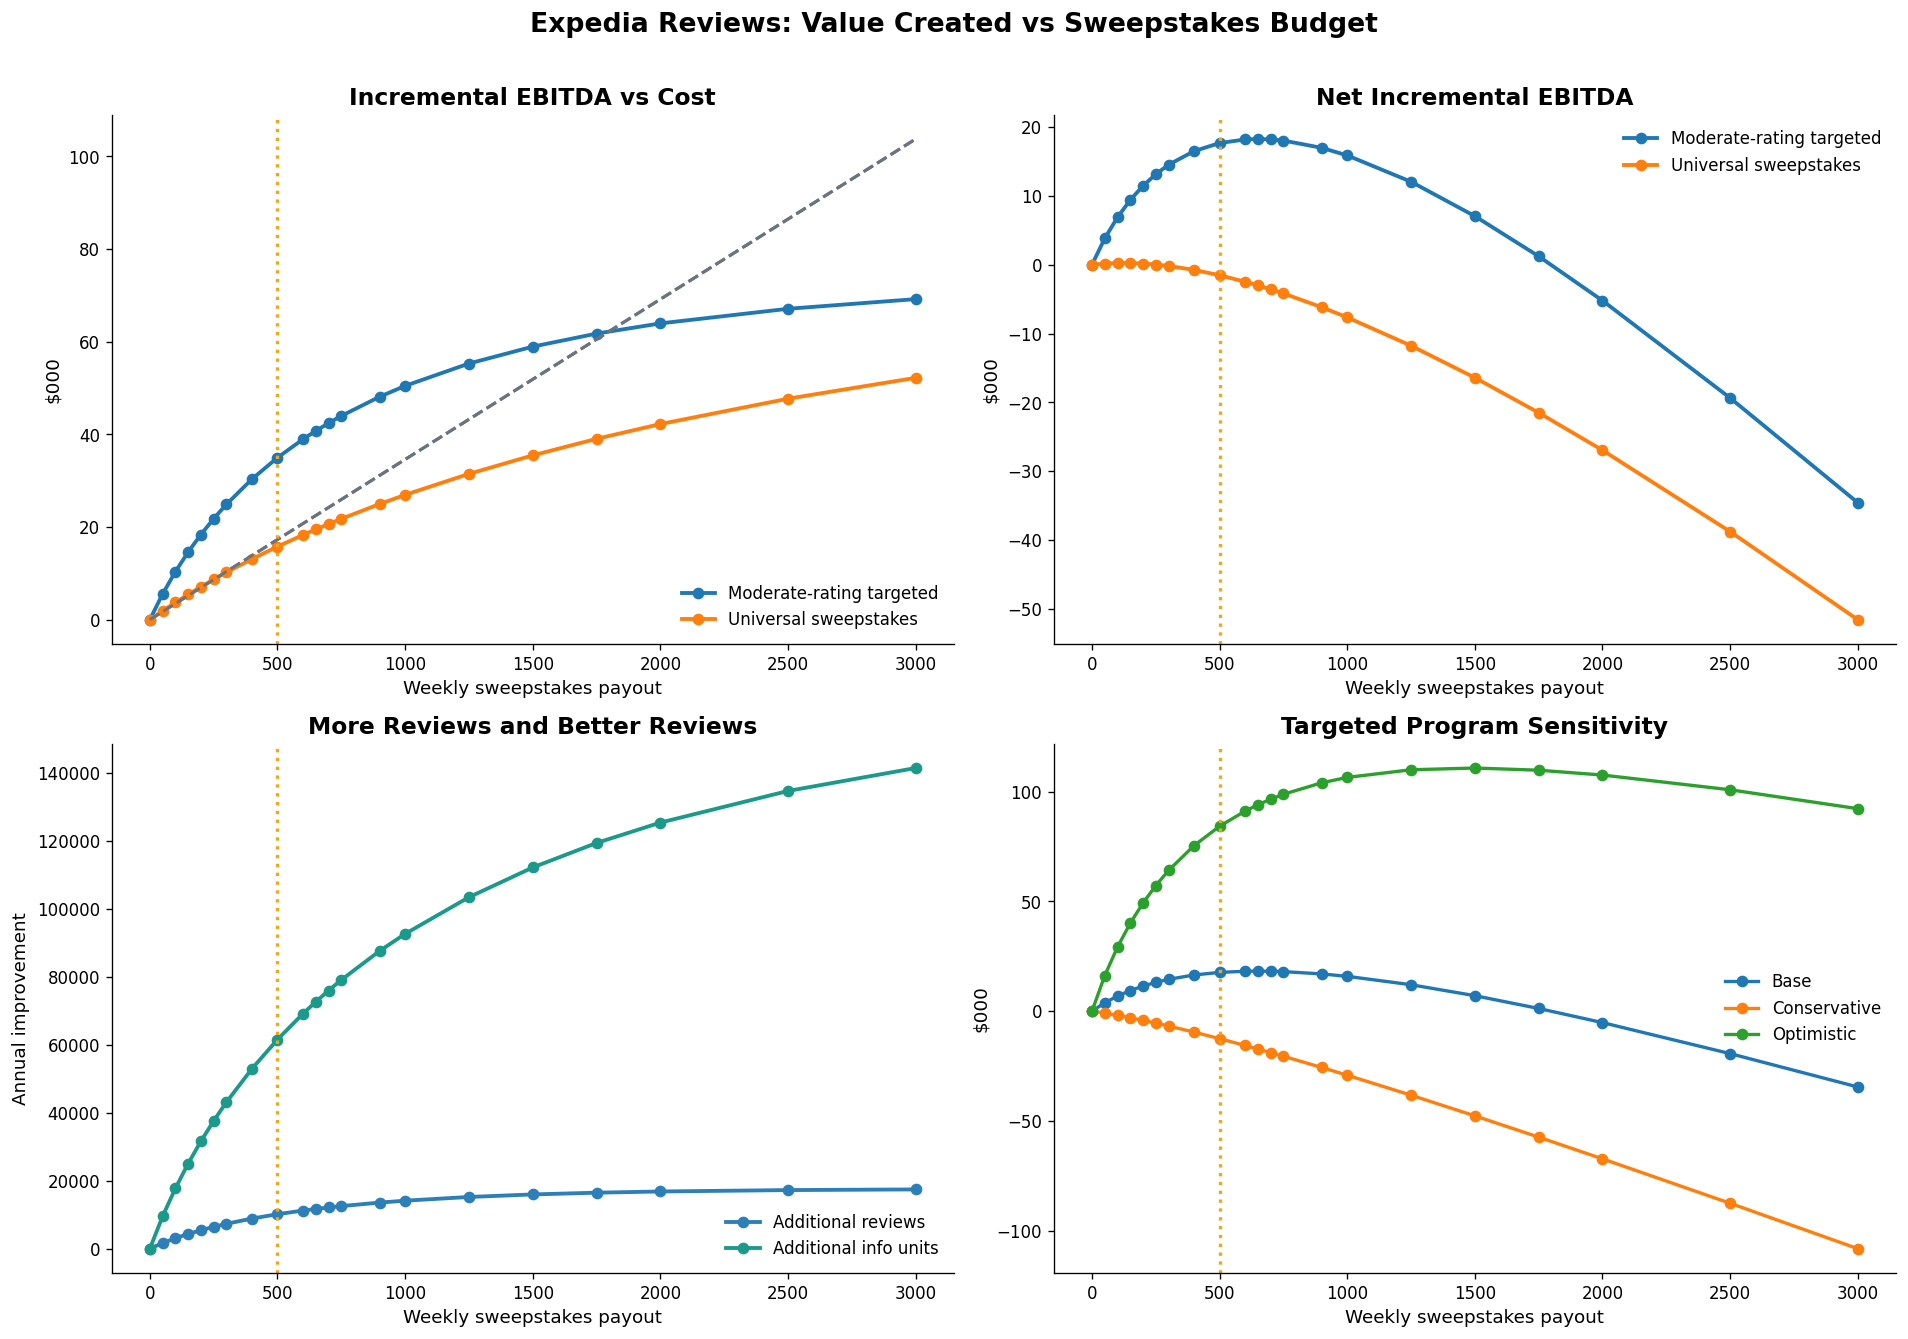

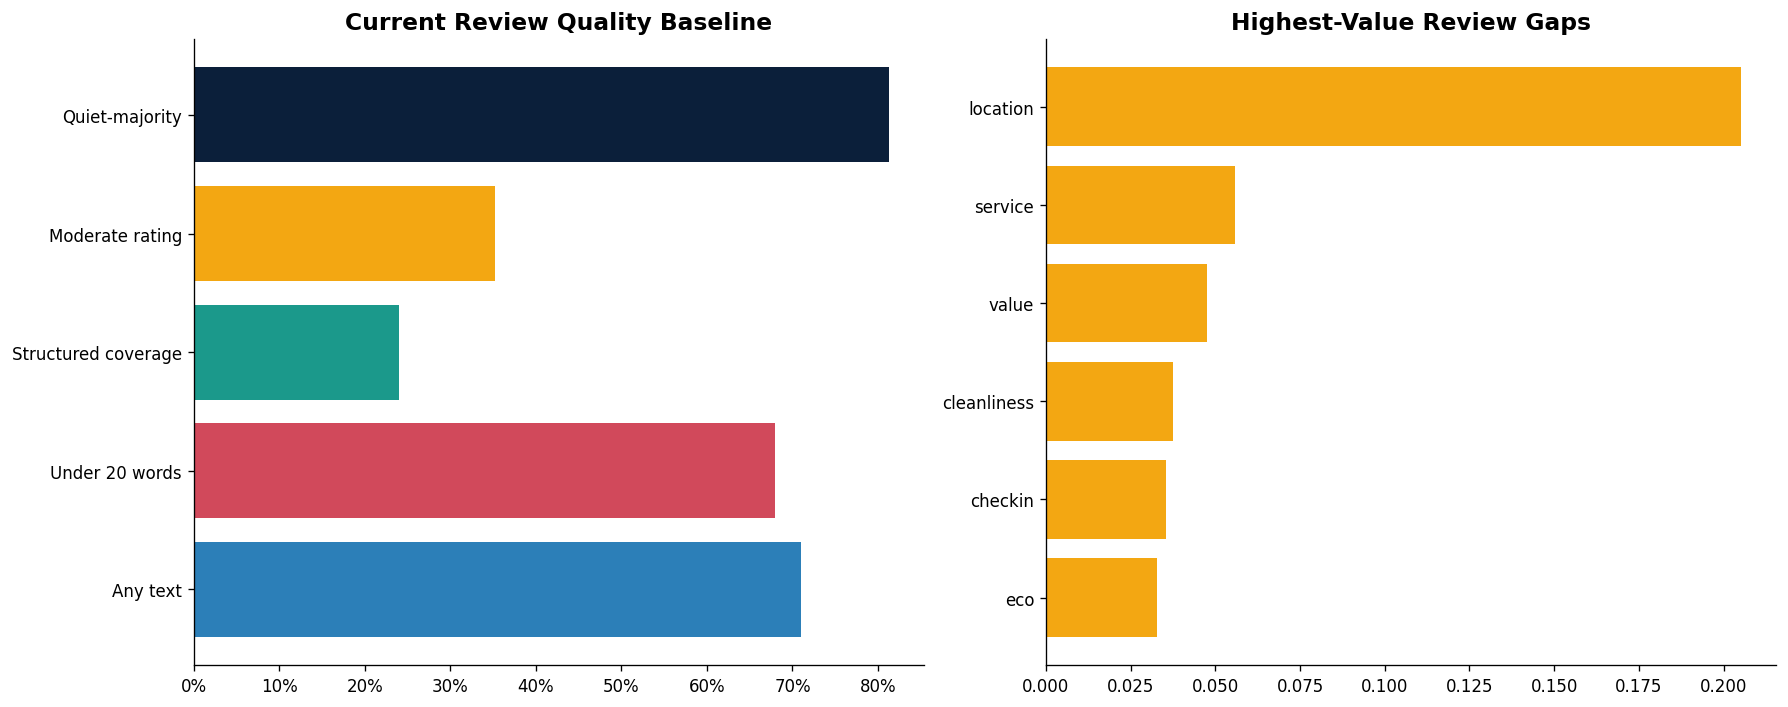

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for scenario_name, df in base_grid.groupby("scenario"):
    axes[0, 0].plot(df["weekly_payout"], df["incremental_ebitda"] / 1_000, marker="o", linewidth=2.3, label=scenario_name)
    axes[0, 0].plot(df["weekly_payout"], df["economic_cost"] / 1_000, linestyle="--", linewidth=1.8, color=PALETTE["gray"])
    axes[0, 1].plot(df["weekly_payout"], df["net_incremental_ebitda"] / 1_000, marker="o", linewidth=2.3, label=scenario_name)

axes[1, 0].plot(targeted_base["weekly_payout"], targeted_base["additional_reviews"], marker="o", color=PALETTE["blue"], linewidth=2.3, label="Additional reviews")
axes[1, 0].plot(targeted_base["weekly_payout"], targeted_base["additional_info_units"], marker="o", color=PALETTE["teal"], linewidth=2.3, label="Additional info units")

for sensitivity_name, df in sensitivity_grid.groupby("sensitivity"):
    axes[1, 1].plot(df["weekly_payout"], df["net_incremental_ebitda"] / 1_000, marker="o", linewidth=2.0, label=sensitivity_name)

axes[0, 0].set_title("Incremental EBITDA vs Cost")
axes[0, 1].set_title("Net Incremental EBITDA")
axes[1, 0].set_title("More Reviews and Better Reviews")
axes[1, 1].set_title("Targeted Program Sensitivity")

for ax in axes.flat:
    ax.axvline(500, color=PALETTE["gold"], linestyle=":", linewidth=2)
    ax.set_xlabel("Weekly sweepstakes payout")

axes[0, 0].set_ylabel("$000")
axes[0, 1].set_ylabel("$000")
axes[1, 0].set_ylabel("Annual improvement")
axes[1, 1].set_ylabel("$000")

axes[0, 0].legend(frameon=False)
axes[0, 1].legend(frameon=False)
axes[1, 0].legend(frameon=False)
axes[1, 1].legend(frameon=False)

fig.suptitle("Expedia Reviews: Value Created vs Sweepstakes Budget", fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
savefig(fig, "01_sweepstakes_financial_dashboard")

top_gaps = gap_topics.head(6).copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(["Any text", "Under 20 words", "Structured coverage", "Moderate rating", "Quiet-majority"], [
    reviews["has_text"].mean(),
    (reviews["word_count"] < 20).mean(),
    reviews["structured_coverage_share"].mean(),
    reviews["moderate_rating"].mean(),
    reviews["quiet_majority_candidate"].mean(),
], color=[PALETTE["blue"], PALETTE["red"], PALETTE["teal"], PALETTE["gold"], PALETTE["navy"]])
axes[0].set_title("Current Review Quality Baseline")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].barh(top_gaps["topic"], top_gaps["gap_score"], color=PALETTE["gold"])
axes[1].invert_yaxis()
axes[1].set_title("Highest-Value Review Gaps")
fig.tight_layout()
savefig(fig, "02_review_gap_snapshot")


## Rollout Framing: Pilot vs Scaled vs Company-Wide

,layer,annual_invites,affected_booking_base_share,sensitivity,framing
0,Pilot,1000000,0.1000,Base,Conservative initial launch; same scope as the...
1,Scaled rollout,10000000,0.6000,Base,Broader rollout across more verified post-stay...
2,Company-wide upside,25000000,1.0000,Optimistic,Expedia-wide upside view with broader review-s...


,layer,sensitivity,annual_invites,targeted_invites,weekly_payout,annual_prize_face_value,incremental_gross_bookings,incremental_revenue,incremental_ebitda,economic_cost,net_incremental_ebitda
0,Pilot,Base,1000000,"351,891.9820",650,33800,"1,220,970.5856","137,926.4231","40,734.4450","22,477.0000","18,257.4450"
1,Scaled rollout,Base,10000000,"3,518,919.8200",3000,156000,"4,476,634.8941","505,701.1576","149,351.0491","103,740.0000","45,611.0491"
2,Company-wide upside,Optimistic,25000000,"8,797,299.5499",15000,780000,"22,837,057.4171","2,579,778.4822","761,897.8460","386,100.0000","375,797.8460"


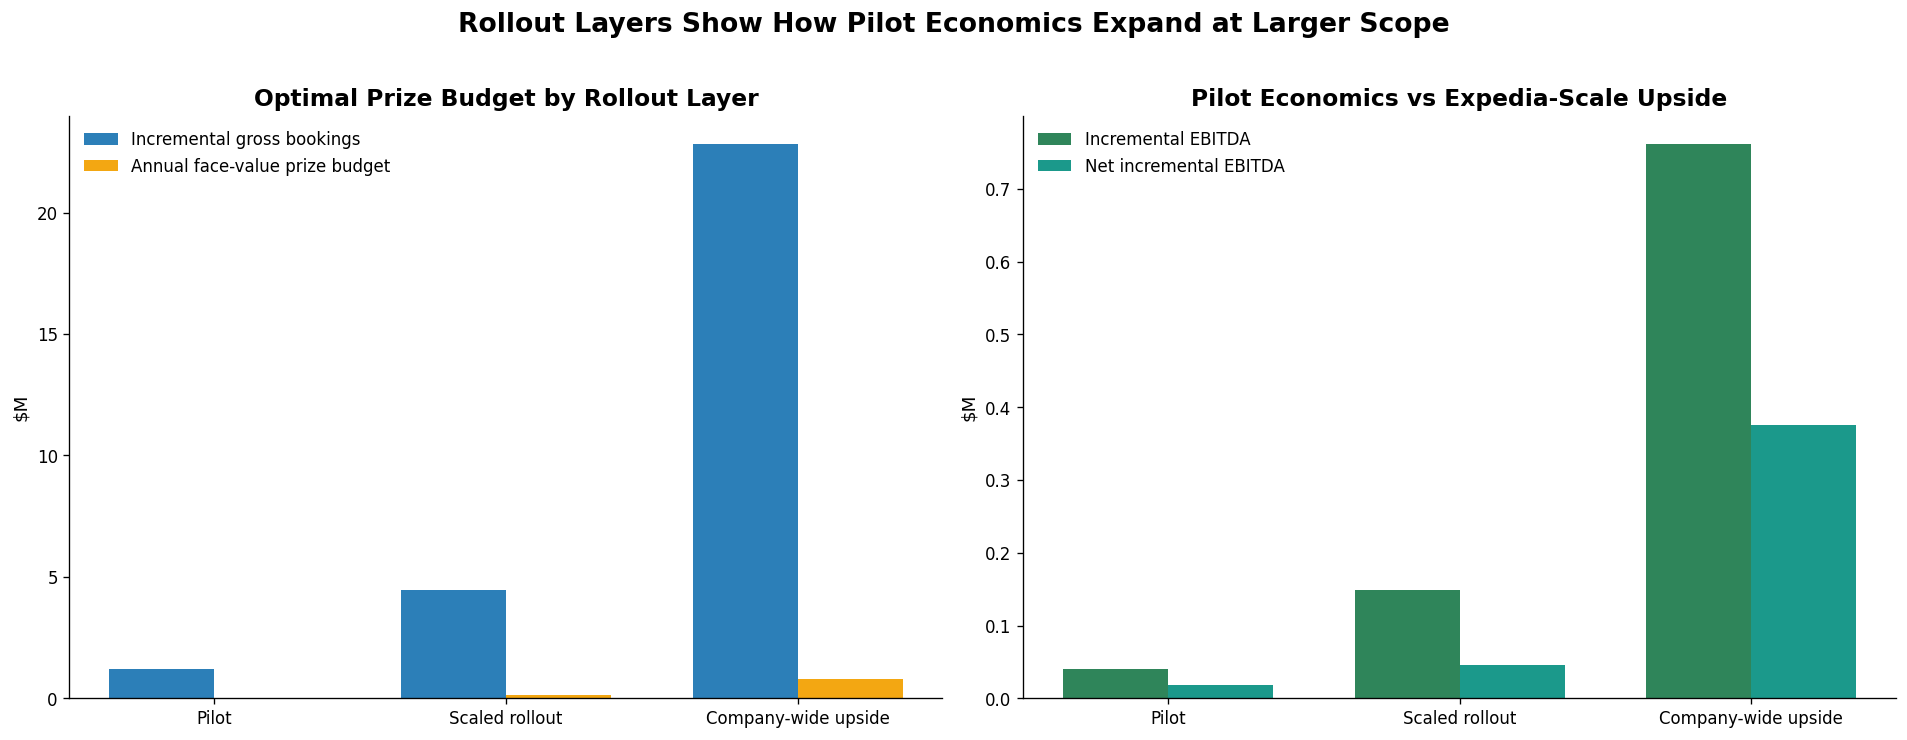

In [6]:
pilot_optimal = targeted_base.sort_values("net_incremental_ebitda", ascending=False).iloc[0]

rollout_specs = [
    {
        "layer": "Pilot",
        "annual_invites": 1_000_000,
        "affected_booking_base_share": 0.10,
        "sensitivity": "Base",
        "weekly_payout_grid": weekly_payout_grid,
        "framing": "Conservative initial launch; same scope as the current base model.",
    },
    {
        "layer": "Scaled rollout",
        "annual_invites": 10_000_000,
        "affected_booking_base_share": 0.60,
        "sensitivity": "Base",
        "weekly_payout_grid": np.array([0, 250, 500, 750, 1000, 1250, 1500, 2000, 2500, 3000, 4000, 5000, 6500, 8000, 10000]),
        "framing": "Broader rollout across more verified post-stay touchpoints and review surfaces.",
    },
    {
        "layer": "Company-wide upside",
        "annual_invites": 25_000_000,
        "affected_booking_base_share": 1.00,
        "sensitivity": "Optimistic",
        "weekly_payout_grid": np.array([0, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000, 6500, 8000, 10000, 12500, 15000, 20000, 25000, 30000]),
        "framing": "Expedia-wide upside view with broader review-surface impact and stronger review-to-booking conversion assumptions.",
    },
]

rollout_rows = []
for layer in rollout_specs:
    layer_results = pd.DataFrame(
        [
            evaluate_program(
                "Moderate-rating targeted",
                weekly_payout,
                layer["sensitivity"],
                annual_invites_override=layer["annual_invites"],
                affected_booking_base_share_override=layer["affected_booking_base_share"],
            )
            for weekly_payout in layer["weekly_payout_grid"]
        ]
    )
    best_row = layer_results.sort_values("net_incremental_ebitda", ascending=False).iloc[0].to_dict()
    best_row["layer"] = layer["layer"]
    best_row["targeted_invites"] = layer["annual_invites"] * scenario_specs["Moderate-rating targeted"]["target_share"]
    best_row["framing"] = layer["framing"]
    rollout_rows.append(best_row)

rollout_summary = pd.DataFrame(rollout_rows)
rollout_assumptions = pd.DataFrame(
    [
        {
            "layer": layer["layer"],
            "annual_invites": layer["annual_invites"],
            "affected_booking_base_share": layer["affected_booking_base_share"],
            "sensitivity": layer["sensitivity"],
            "framing": layer["framing"],
        }
        for layer in rollout_specs
    ]
)

rollout_assumptions.to_csv(OUTPUT_DIR / "rollout_layer_assumptions.csv", index=False)
rollout_summary.to_csv(OUTPUT_DIR / "rollout_layer_summary.csv", index=False)

display(Markdown("## Rollout Framing: Pilot vs Scaled vs Company-Wide"))
display(rollout_assumptions)
display(
    rollout_summary[
        [
            "layer",
            "sensitivity",
            "annual_invites",
            "targeted_invites",
            "weekly_payout",
            "annual_prize_face_value",
            "incremental_gross_bookings",
            "incremental_revenue",
            "incremental_ebitda",
            "economic_cost",
            "net_incremental_ebitda",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(rollout_summary))
width = 0.36

axes[0].bar(x - width / 2, rollout_summary["incremental_gross_bookings"] / 1_000_000, width=width, color=PALETTE["blue"], label="Incremental gross bookings")
axes[0].bar(x + width / 2, rollout_summary["annual_prize_face_value"] / 1_000_000, width=width, color=PALETTE["gold"], label="Annual face-value prize budget")
axes[0].set_xticks(x)
axes[0].set_xticklabels(rollout_summary["layer"])
axes[0].set_ylabel("$M")
axes[0].set_title("Optimal Prize Budget by Rollout Layer")
axes[0].legend(frameon=False)

axes[1].bar(x - width / 2, rollout_summary["incremental_ebitda"] / 1_000_000, width=width, color=PALETTE["green"], label="Incremental EBITDA")
axes[1].bar(x + width / 2, rollout_summary["net_incremental_ebitda"] / 1_000_000, width=width, color=PALETTE["teal"], label="Net incremental EBITDA")
axes[1].set_xticks(x)
axes[1].set_xticklabels(rollout_summary["layer"])
axes[1].set_ylabel("$M")
axes[1].set_title("Pilot Economics vs Expedia-Scale Upside")
axes[1].legend(frameon=False)

fig.suptitle("Rollout Layers Show How Pilot Economics Expand at Larger Scope", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "03_rollout_layers")


In [7]:
targeted_optimal = targeted_base.sort_values("net_incremental_ebitda", ascending=False).iloc[0]
current_ui = targeted_base.loc[targeted_base["weekly_payout"] == 500].iloc[0]
universal_optimal = base_optima.loc[base_optima["scenario"] == "Universal sweepstakes"].iloc[0]
pilot_rollout = rollout_summary.loc[rollout_summary["layer"] == "Pilot"].iloc[0]
scaled_rollout = rollout_summary.loc[rollout_summary["layer"] == "Scaled rollout"].iloc[0]
enterprise_rollout = rollout_summary.loc[rollout_summary["layer"] == "Company-wide upside"].iloc[0]

optimization_summary = pd.DataFrame(
    [
        {"view": "Base optimal targeted program", **targeted_optimal.to_dict()},
        {"view": "Current UI payout ($500/week)", **current_ui.to_dict()},
        {"view": "Base optimal universal program", **universal_optimal.to_dict()},
    ]
)
optimization_summary.to_csv(OUTPUT_DIR / "optimization_summary.csv", index=False)

recommendation = (
    "## Recommendation\n\n"
    f"- **Pilot recommendation**: about **${int(targeted_optimal['weekly_payout'])}/week** for the moderate-rating targeted program.\n"
    f"- In the pilot-scale base case, that corresponds to **{usd(targeted_optimal['annual_prize_face_value'])}** of annual face-value budget, **{usd(targeted_optimal['incremental_revenue'])}** of incremental revenue, **{usd(targeted_optimal['incremental_ebitda'])}** of incremental EBITDA, and **{usd(targeted_optimal['net_incremental_ebitda'])}** of net value.\n"
    f"- The current **$500/week** demo design is **close to optimal**: it still delivers about **{usd(current_ui['net_incremental_ebitda'])}** of net incremental EBITDA in the base case.\n"
    f"- A universal sweepstakes is much weaker; its best tested payout only produces about **{usd(universal_optimal['net_incremental_ebitda'])}** of net value.\n"
    f"- If Expedia scales the same incentive intensity beyond the pilot, the model shows much larger upside: the **Scaled rollout** layer reaches about **{usd(scaled_rollout['incremental_revenue'])}** revenue and **{usd(scaled_rollout['net_incremental_ebitda'])}** net EBITDA, while the **Company-wide upside** layer reaches about **{usd(enterprise_rollout['incremental_revenue'])}** revenue and **{usd(enterprise_rollout['net_incremental_ebitda'])}** net EBITDA.\n"
    "- Best pitch framing: keep the clean **$500/week** UX in the demo for the pilot, and use the rollout table to show how the same product logic can expand into Expedia-scale economics."
)

display(Markdown(recommendation))
display(Markdown("## Optimization Summary"))
display(optimization_summary[["view", "weekly_payout", "annual_prize_face_value", "additional_reviews", "additional_info_units", "incremental_revenue", "incremental_ebitda", "economic_cost", "net_incremental_ebitda"]])


## Recommendation

- **Pilot recommendation**: about **$650/week** for the moderate-rating targeted program.
- In the pilot-scale base case, that corresponds to **$33,800.00** of annual face-value budget, **$137,926.42** of incremental revenue, **$40,734.44** of incremental EBITDA, and **$18,257.44** of net value.
- The current **$500/week** demo design is **close to optimal**: it still delivers about **$17,671.91** of net incremental EBITDA in the base case.
- A universal sweepstakes is much weaker; its best tested payout only produces about **$250.74** of net value.
- If Expedia scales the same incentive intensity beyond the pilot, the model shows much larger upside: the **Scaled rollout** layer reaches about **$505,701.16** revenue and **$45,611.05** net EBITDA, while the **Company-wide upside** layer reaches about **$2,579,778.48** revenue and **$375,797.85** net EBITDA.
- Best pitch framing: keep the clean **$500/week** UX in the demo for the pilot, and use the rollout table to show how the same product logic can expand into Expedia-scale economics.

## Optimization Summary

,view,weekly_payout,annual_prize_face_value,additional_reviews,additional_info_units,incremental_revenue,incremental_ebitda,economic_cost,net_incremental_ebitda
0,Base optimal targeted program,650,33800,"11,681.4974","72,641.5635","137,926.4231","40,734.4450","22,477.0000","18,257.4450"
1,Current UI payout ($500/week),500,26000,"10,133.0661","61,546.9268","118,380.6801","34,961.9108","17,290.0000","17,671.9108"
2,Base optimal universal program,100,5200,"2,802.9432","19,409.2630","12,557.7631","3,708.7420","3,458.0000",250.7420
